In [1]:
import scanpy as sc
import scvi
from tqdm.notebook import tqdm
import os
import numpy as np
import pandas as pd
from scvi.model.utils import mde
import matplotlib.pyplot as plt
import pickle
import glob
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch

Global seed set to 0


In [2]:
#input_file = '/mnt/sata2/projects/Spatial/Tumor'
input_folders = glob.glob(os.path.join('/mnt/sata3/projects/kbennion/Spatial_Data/output-XETG00195__0043449__TIS09322-001__20250213__230552/xenium_analysis', 'tumor*'))
input_folders

['/mnt/sata3/projects/kbennion/Spatial_Data/output-XETG00195__0043449__TIS09322-001__20250213__230552/xenium_analysis/tumor_1']

In [3]:
adatalist=[]
for input_file in input_folders:
    adata = sc.read(os.path.join(input_file, "adatas", '04_tissue_cleared.h5ad'))
    name = os.path.basename(input_file)
    adata.obs['batch'] = name
    adatalist.append(adata)

In [4]:
adata=sc.concat(adatalist)

In [5]:
adata.layers["counts"] = adata.X
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
vae.train()

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/18:   0%|          | 0/18 [00:00<?, ?it/s]

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.



Epoch 18/18: 100%|██████████| 18/18 [07:41<00:00, 24.75s/it, loss=1.28e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=18` reached.


Epoch 18/18: 100%|██████████| 18/18 [07:41<00:00, 25.66s/it, loss=1.28e+03, v_num=1]


In [6]:
adata.obsm["X_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scVI")

/home/angelica/miniforge3/envs/xenium_dev/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [7]:
adata.obsm["X_mde"] = mde(adata.obsm["X_scVI"])


Apr 21 02:09:30 PM: Your dataset appears to contain duplicated items (rows); when embedding, you should typically have unique items.
Apr 21 02:09:30 PM: The following items have duplicates [ 31633  59571  96348  99395 104572 104628 104670 104725 104733 104870
 104921 104924 104993 105084 105093 108943 109362 109410 109436 114040
 114624 115452 115794 116058 116363 116515 116874 116875 116901 122726
 124045 126075 128022 128545 128551 128612 135133 136279 206346 206683
 212210 219186 224068 224106 224107 224115 224141 224143 224155 224175
 224191 224193 224213 224215 224227 224239 224387 224427 224447 224476
 224479 224615 224640 224641 224786 224796 224819 224884 226079 226268
 226308 226369 226488 226513 226634 229510 249702 251658 302303 305043
 309810 313240 313590 313830 314442 314582 314657 314887 315303 320888
 325644 325722 326184 327216 328527 399698 436718 437577 438374 438481
 438718 441876 442062 448087 448114 448126 448273 448485 448573 449119
 449746 449776 449836 450529]


In [12]:
sc.tl.leiden(adata, resolution = 1.5)

/tmp/ipykernel_1715667/665308462.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 1.5)


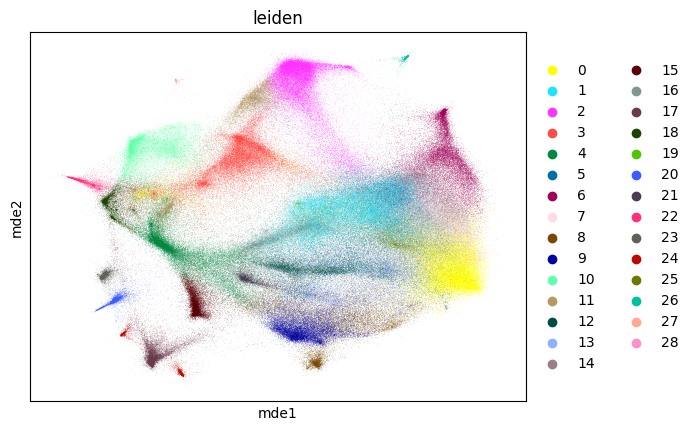

In [13]:
sc.pl.embedding(adata,basis="mde",color="leiden")

In [14]:
try:
    os.mkdir(os.path.join(os.path.dirname(input_file), "combined"))
except:
    print("booyah")


In [15]:
adata.write(os.path.join(os.path.dirname(input_file), "combined", '05_scvi.h5ad'))